In [1]:
import earthkit.hydro as ekh
import numpy as np
import matplotlib.pyplot as plt

network = ekh.river_network.load("efas", "5", use_cache=False)

Cache disabled.
Cache disabled.


# Computing accumulations along rivers

There are two different types of flow accumulations: 
1. full flow accumulations (global aggregation)
2. one-step neighbor accumulations (local aggregation).

## Global aggregation

Global aggregations from sources to sinks can computed via the `ekh.upstream` submodule, and aggregations from sinks to sources can be computed using the `ekh.downstream` submodule.

Many different aggregations are possible, namely `sum`, `min`, `max`, `mean`, `var`, `std`.

In [11]:
field = np.random.rand(*network.shape) # or load array/xarray from file

da1 = ekh.upstream.array.percentile(network, field, p=0.5, return_type="masked")

da1

array([0.56948839, 0.71608442, 0.1241944 , ..., 0.31062138, 0.7361542 ,
       0.31592083])

In [9]:
weights = np.ones(network.shape) #np.random.rand(*network.shape) # or load array/xarray from file

da2 = ekh.upstream.array.percentile(network, field, p=0.5, node_weights=weights, return_type="masked")

da2

weights are not None, using weighted percentile


array([0.13745448, 0.46823695, 0.34064713, ..., 0.7671697 , 0.51422346,
       0.8192985 ])

In [10]:
np.testing.assert_array_equal(da1, da2)

## Local aggregation

Local aggregations can be computed using the `move` submodule, and the same metrics are available.

Below we show an example using `move.downstream` to find the number of gridcells draining to each point.

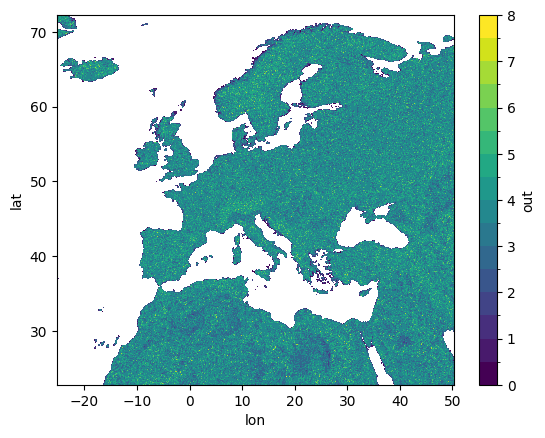

In [ ]:
da = ekh.move.downstream(network, field, metric="sum")

da.plot.contourf(cmap="viridis", levels=20)
plt.show()